In [15]:
print(" HAPPY LEARNING")

 HAPPY LEARNING


In [9]:
# %%
print("WELCOME TO IRIS SPECIES REPORT")

# %%
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    mean_squared_error,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import shap

WELCOME TO IRIS SPECIES REPORT


In [11]:

df = pd.read_csv("Iris.csv")
df = df.drop(columns=["Id"])   # Id is not a real feature, just a row number

print("Shape of data:", df.shape)
print(df.info())
print(df.describe())

Shape of data: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.80

Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

Features most correlated with species:
PetalWidthCm     0.956464
PetalLengthCm    0.949043
SepalLengthCm    0.782561
SepalWidthCm    -0.419446
Name: Species_enc, dtype: float64


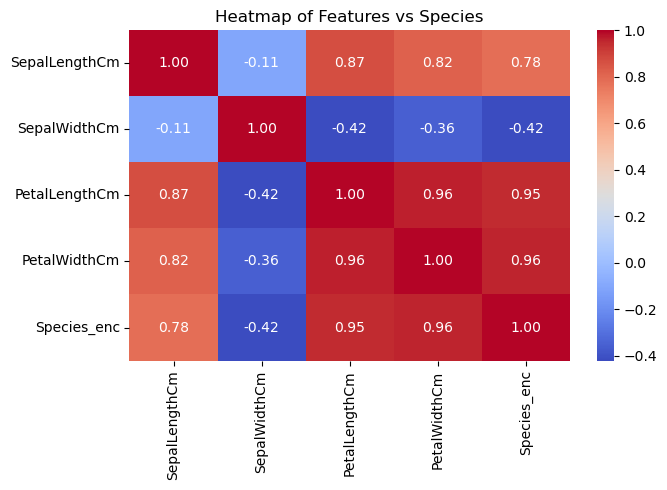

In [12]:

le = LabelEncoder()
df["Species_enc"] = le.fit_transform(df["Species"])
print("Classes:", list(le.classes_))

feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
correlation = df[feature_cols + ["Species_enc"]].corr()["Species_enc"]
correlation = correlation.drop("Species_enc")
correlation = correlation.sort_values(key=abs, ascending=False)
print("\nFeatures most correlated with species:")
print(correlation)

# %%
plt.figure(figsize=(7, 5))
sns.heatmap(df[feature_cols + ["Species_enc"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of Features vs Species")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()
plt.close()

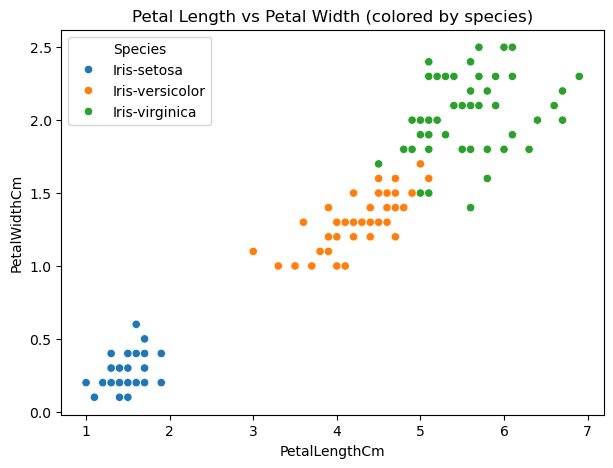

In [13]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species"
)
plt.title("Petal Length vs Petal Width (colored by species)")
plt.savefig("scatter_plot.png")
plt.show()
plt.close()

In [14]:
X = df[feature_cols]
y = df["Species_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance the training data using SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Train shape before SMOTE:", X_train_scaled.shape, np.bincount(y_train))
print("Train shape after SMOTE:", X_train_bal.shape, np.bincount(y_train_bal))

Train shape before SMOTE: (120, 4) [40 40 40]
Train shape after SMOTE: (120, 4) [40 40 40]


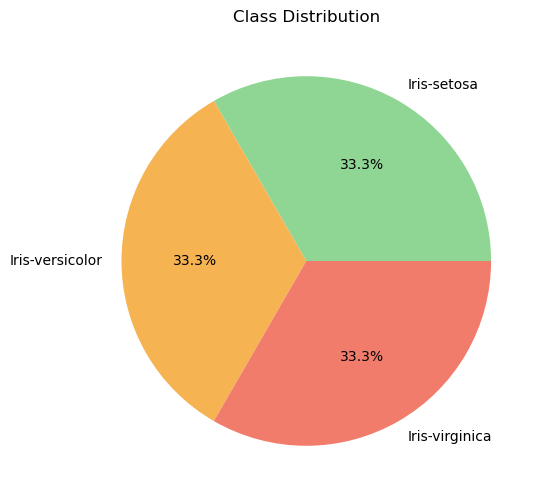

In [15]:
plt.figure(figsize=(6, 6))
df["Species"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["#8FD694", "#F6B352", "#F27C6C"]
)
plt.title("Class Distribution")
plt.ylabel("")
plt.savefig("pie_chart.png")
plt.show()
plt.close()




In [16]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_bal, y_train_bal)
y_pred_lr = model_lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr, average="macro")
f1_lr = f1_score(y_test, y_pred_lr, average="macro")
mse_lr = mean_squared_error(y_test, y_pred_lr)

print("Logistic Regression Results")
print("Accuracy:", acc_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)
print("MSE:", mse_lr)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Logistic Regression Results
Accuracy: 0.9333333333333333
Recall: 0.9333333333333332
F1 Score: 0.9333333333333332
MSE: 0.06666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [17]:
model_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
model_dt.fit(X_train_bal, y_train_bal)
y_pred_dt = model_dt.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt, average="macro")
f1_dt = f1_score(y_test, y_pred_dt, average="macro")
mse_dt = mean_squared_error(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy:", acc_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)
print("MSE:", mse_dt)
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Decision Tree Results
Accuracy: 0.9
Recall: 0.9
F1 Score: 0.899749373433584
MSE: 0.1
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



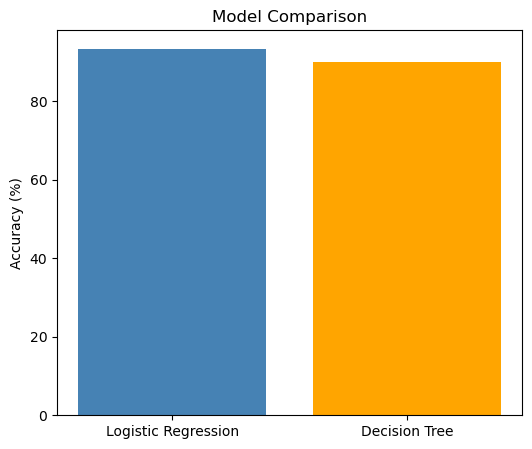

In [18]:
models = ["Logistic Regression", "Decision Tree"]
accuracies = [acc_lr * 100, acc_dt * 100]

plt.figure(figsize=(6, 5))
plt.bar(models, accuracies, color=["steelblue", "orange"])
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.savefig("model_comparison.png")
plt.show()
plt.close()

# %%
if acc_lr >= acc_dt:
    best_name = "Logistic Regression"
    best_model = model_lr
    best_preds = y_pred_lr
else:
    best_name = "Decision Tree"
    best_model = model_dt
    best_preds = y_pred_dt


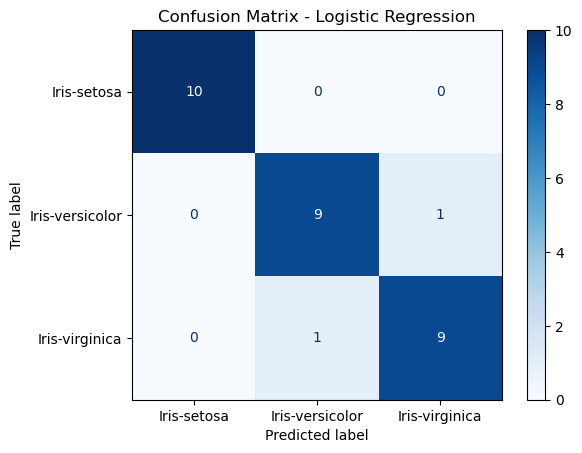

In [19]:
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - " + best_name)
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()

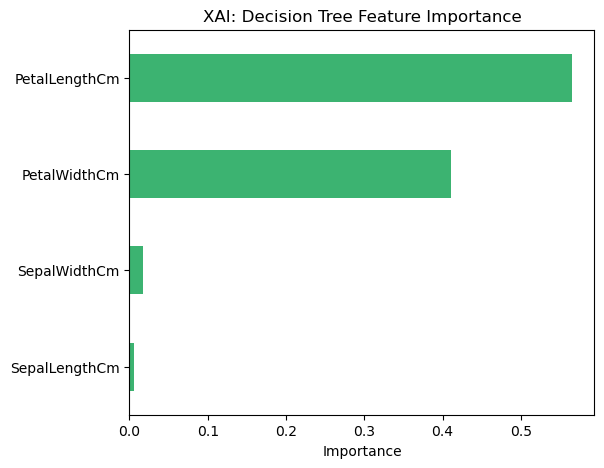

SepalLengthCm    0.006329
SepalWidthCm     0.016878
PetalWidthCm     0.411154
PetalLengthCm    0.565639
dtype: float64


In [26]:
importances = pd.Series(model_dt.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(6, 5))
importances.plot.barh(color="mediumseagreen")
plt.title("XAI: Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.savefig("xai_dt_importance.png")
plt.show()
plt.close()

print(importances)



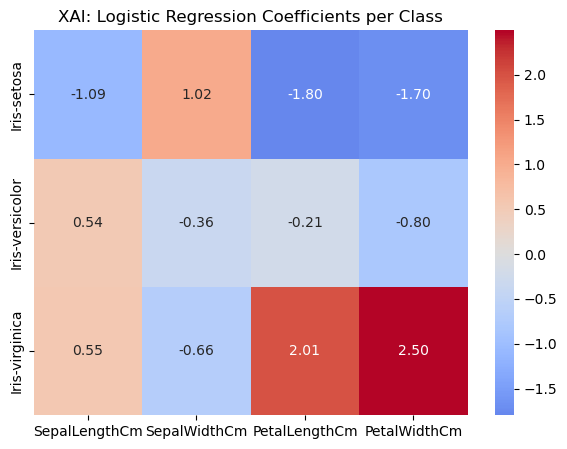

                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Iris-setosa          -1.091782      1.020342      -1.797617     -1.695241
Iris-versicolor       0.538893     -0.359539      -0.207911     -0.800662
Iris-virginica        0.552890     -0.660802       2.005529      2.495903


In [28]:
coef_df = pd.DataFrame(model_lr.coef_, columns=feature_cols, index=le.classes_)
plt.figure(figsize=(7, 5))
sns.heatmap(coef_df, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("XAI: Logistic Regression Coefficients per Class")
plt.savefig("xai_lr_coef.png")
plt.show()
plt.close()

print(coef_df)


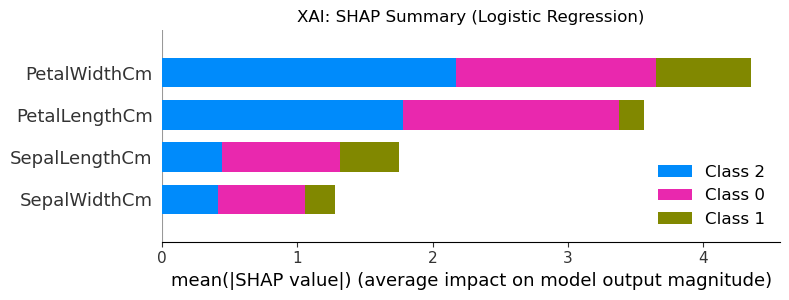

In [22]:
explainer = shap.Explainer(model_lr, X_train_scaled, feature_names=feature_cols)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols, show=False)
plt.title("XAI: SHAP Summary (Logistic Regression)")
plt.tight_layout()
plt.savefig("xai_shap_summary.png")
plt.show()
plt.close()

In [23]:
print("my heartiest gratitude to you for viewing it")

my heartiest gratitude to you for viewing it
